In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def safe_select(grouped, cols):
    """Safely select columns from a grouped DataFrame."""
    return grouped[cols] if len(cols) > 0 else pd.DataFrame(index=grouped.index)


In [3]:
def unwrap_scalar(v):
    if isinstance(v, (list, tuple)) and len(v) == 1:
        return v[0]
    return v


In [4]:
def plot_reward(path):

    df = pd.read_csv(path)

    df = df.dropna(
        subset=["episode_reward_mean", "episode_reward_max", "episode_reward_min"]
    )

    iters = df["training_iteration"]

    plt.figure(figsize=(10, 6)) 
    plt.plot(iters, df["episode_reward_mean"], label="Mean Reward")
    plt.fill_between(
        iters,
        df["episode_reward_min"],
        df["episode_reward_max"],
        alpha=0.2,
        label="Min–Max Range"
    )
    plt.xlabel("Training Iteration")
    plt.ylabel("Episode Reward")
    plt.title("Training Rewards Over Time")
    plt.legend()
    plt.grid(True)
    plt.show()


In [5]:
def plot_constrains(csv_path, ax_g, metric_cols, references, reducer="mean"):
    import pandas as pd

    df = pd.read_csv(csv_path)

    # 1) Validate step
    if "step" not in df.columns:
        ax_g.set_title("No step column found")
        ax_g.axis("off")
        return

    # 2) Validate metrics
    missing = [m for m in metric_cols if m not in df.columns]
    if missing:
        raise ValueError(f"Columns not found in CSV: {missing}")
    if not metric_cols:
        ax_g.set_title("No metrics provided")
        ax_g.axis("off")
        return

    # 3) Group by step (choose reducer)
    valid_reducers = {"mean", "sum", "median", "min", "max"}
    if reducer not in valid_reducers:
        raise ValueError(f"Invalid reducer='{reducer}'. Use one of {sorted(valid_reducers)}")

    grouped = (
        df.groupby("step")[metric_cols]
          .agg(reducer)
          .reset_index()
          .sort_values("step")
    )

    # 4) Plot aggregated series
    for m in metric_cols:
        if m == "total_import" or m == "total_export":
            ax_g.plot(grouped["step"], grouped[m], linestyle="--", linewidth=2.0, label=f"{m} ({reducer})")
        else:
            ax_g.plot(grouped["step"], grouped[m], linewidth=2.0, label=f"{m} ({reducer})")


    if references is not None:
        ax_g.axhline(
            y=references[0],
            linestyle=":",
            linewidth=3,
            color="black",
            label="Reference Power"
        )

    ax_g.set_title("Metrics grouped by step")
    ax_g.set_xlabel("step")
    ax_g.set_ylabel("Value")
    ax_g.legend()
    ax_g.grid(alpha=0.3)

In [6]:
def plot_lagrange_multipliers(csv_path, ax, lm_columns=None):
    """
    Plot one or multiple Lagrange multipliers (lm1, lm2, ...)
    aggregated per episode.

    Parameters
    ----------
    csv_path : str
    ax : matplotlib axis
    lm_columns : list[str] or None
        If None, automatically selects all columns starting with 'lm'.
    """

    import pandas as pd

    df = pd.read_csv(csv_path)

    if "step" not in df.columns:
        ax.set_title("No episode column found")
        ax.axis("off")
        return

    # --- Auto-detect lm columns if not provided ---
    if lm_columns is None:
        lm_columns = [c for c in df.columns if c.startswith("mu")]

    if not lm_columns:
        ax.set_title("No Lagrange multipliers found")
        ax.axis("off")
        return

    # --- Aggregate per episode ---
    agg_dict = {}
    for lm in lm_columns:
        agg_dict[f"{lm}_mean"] = (lm, "mean")
        agg_dict[f"{lm}_min"] = (lm, "min")
        agg_dict[f"{lm}_max"] = (lm, "max")

    stats = (
        df.groupby("step")
          .agg(**agg_dict)
          .reset_index()
    )

    # --- Plot each multiplier ---
    for lm in lm_columns:
        ax.plot(
            stats["step"],
            stats[f"{lm}_mean"],
            linewidth=2,
            label=f"{lm} mean"
        )

        ax.fill_between(
            stats["step"],
            stats[f"{lm}_min"],
            stats[f"{lm}_max"],
            alpha=0.2,
            label=f"{lm} range"
        )

    ax.set_title("Market price per step")
    ax.set_xlabel("step")
    ax.set_ylabel("Value")
    ax.set_ylim([10,100])
    ax.legend()
    ax.grid(alpha=0.3)


In [7]:
import ast
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


def _parse_list_cell(x):
    """Parsea celdas tipo '[...]' a lista de floats. Devuelve None si falla."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    if isinstance(x, (list, tuple, np.ndarray)):
        return list(x)
    if not isinstance(x, str):
        return None

    s = x.strip()
    if not s:
        return None

    try:
        v = ast.literal_eval(s)
        if isinstance(v, (list, tuple, np.ndarray)):
            return list(v)
        return None
    except Exception:
        return None


def _expand_1d_list_col(df, col, prefix=None, max_len=None):
    """
    Expande una columna que contiene listas serializadas a columnas escalares:
      col='ask_q' -> ask_q_0..ask_q_{k-1}
    """
    if col not in df.columns:
        return df, 0

    prefix = prefix or col
    parsed = df[col].apply(_parse_list_cell)

    if max_len is None:
        lens = parsed.dropna().apply(len)
        if len(lens) == 0:
            return df, 0
        max_len = int(lens.max())

    for k in range(max_len):
        df[f"{prefix}_{k}"] = parsed.apply(
            lambda v: float(v[k]) if (v is not None and len(v) > k and v[k] is not None) else np.nan
        )

    return df, max_len


def _expand_pair_matrix(df, col, n_sellers=None, n_buyers=None, prefix=None):
    """
    Expande una columna serializada tipo vector de longitud n_sellers*n_buyers
    a columnas escalares:
      prefix_s0_b0, prefix_s0_b1, ..., prefix_s{n_s-1}_b{n_b-1}
    """
    if col not in df.columns:
        return df

    prefix = prefix or col
    parsed = df[col].apply(_parse_list_cell)
    lens = parsed.dropna().apply(len)
    if len(lens) == 0:
        return df

    L = int(lens.max())

    if n_sellers is not None and n_buyers is not None and n_sellers * n_buyers == L:
        for s in range(n_sellers):
            for b in range(n_buyers):
                k = s * n_buyers + b
                df[f"{prefix}_s{s}_b{b}"] = parsed.apply(
                    lambda v: float(v[k]) if (v is not None and len(v) > k and v[k] is not None) else np.nan
                )
    else:
        for k in range(L):
            df[f"{prefix}_{k}"] = parsed.apply(
                lambda v: float(v[k]) if (v is not None and len(v) > k and v[k] is not None) else np.nan
            )

    return df


def _plot_pair_subplots(
    fig,
    outer_spec,
    grouped,
    n_sellers,
    n_buyers,
    value_prefix,
    title,
    ylabel,
    ylim=None,
    mask_with_p=False,
    linewidth=2.0,
    ncols=3,
    overlay_mode=None,   # None | "quantity" | "price"
):
    """
    Dibuja una rejilla de subplots pequeños, uno por par seller->buyer.

    - Si value_prefix="P" y overlay_mode="quantity":
        grafica P_sX_bY + ask_q_sX + bid_q_bY
    - Si value_prefix="M" y overlay_mode="price":
        grafica M_sX_bY + ask_p_sX + bid_p_bY

    Si mask_with_p=True, oculta la serie principal cuando P_sX_bY == 0.
    """
    pair_data = []

    for s in range(n_sellers):
        for b in range(n_buyers):
            val_col = f"{value_prefix}_s{s}_b{b}"
            if val_col not in grouped.columns:
                continue

            y_main = grouped[val_col].astype(float).copy()

            if mask_with_p:
                p_col = f"P_s{s}_b{b}"
                if p_col in grouped.columns:
                    p = grouped[p_col].astype(float)
                    y_main = y_main.where(p > 1e-9, np.nan)

            # overlays
            y_ask = None
            y_bid = None

            if overlay_mode == "quantity":
                ask_col = f"ask_q_{s}"
                bid_col = f"bid_q_{b}"
                if ask_col in grouped.columns:
                    y_ask = grouped[ask_col].astype(float).copy()
                if bid_col in grouped.columns:
                    y_bid = grouped[bid_col].astype(float).copy()

            elif overlay_mode == "price":
                ask_col = f"ask_p_{s}"
                bid_col = f"bid_p_{b}"
                if ask_col in grouped.columns:
                    y_ask = grouped[ask_col].astype(float).copy()
                if bid_col in grouped.columns:
                    y_bid = grouped[bid_col].astype(float).copy()

            pair_data.append((s, b, y_main, y_ask, y_bid))

    if len(pair_data) == 0:
        ax_empty = fig.add_subplot(outer_spec)
        ax_empty.text(0.5, 0.5, f"No data available for {value_prefix}", ha="center", va="center")
        ax_empty.set_title(title)
        ax_empty.axis("off")
        return

    n_pairs = len(pair_data)
    ncols = min(ncols, n_pairs)
    nrows = math.ceil(n_pairs / ncols)

    subgs = outer_spec.subgridspec(nrows, ncols, hspace=0.40, wspace=0.25)
    steps = grouped.index.values

    axes = []
    for i, (s, b, y_main, y_ask, y_bid) in enumerate(pair_data):
        r = i // ncols
        c = i % ncols
        ax = fig.add_subplot(subgs[r, c])

        # serie principal
        ax.plot(
            steps, y_main.values,
            linewidth=linewidth,
            label=value_prefix
        )

        # overlays
        if y_ask is not None:
            ax.plot(
                steps, y_ask.values,
                linestyle="--",
                linewidth=max(1.4, linewidth - 0.4),
                label=f"ask_s{s}"
            )

        if y_bid is not None:
            ax.plot(
                steps, y_bid.values,
                linestyle=":",
                linewidth=max(1.4, linewidth - 0.4),
                label=f"bid_b{b}"
            )

        ax.set_title(f"{value_prefix}: s{s}→b{b}", fontsize=10)
        ax.set_xlabel("step")
        ax.set_ylabel(ylabel)

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.grid(alpha=0.3)
        ax.legend(fontsize=7)

        axes.append(ax)

    # apagar subplots vacíos
    for j in range(n_pairs, nrows * ncols):
        r = j // ncols
        c = j % ncols
        ax = fig.add_subplot(subgs[r, c])
        ax.axis("off")

    # título general del bloque
    if axes:
        axes[0].text(
            0.0, 1.22, title,
            transform=axes[0].transAxes,
            fontsize=12,
            fontweight="bold",
            ha="left"
        )

def full_analysis_plot(training_path, eval_path, mu_path, seller_power_reference=None):
    linewidth = 2.2

    # --- Load data ---
    df_train = pd.read_csv(training_path)
    df_eval = pd.read_csv(eval_path)

    df_train = df_train.dropna(
        subset=[
            "env_runners/episode_return_mean",
            "env_runners/episode_return_max",
            "env_runners/episode_return_min",
        ]
    )

    # --- Column detection ---
    A0_cols = [c for c in df_eval.columns if c.startswith("A0_") and c.endswith("_state_2")]
    A1_cols = [c for c in df_eval.columns if c.startswith("A1_") and c.endswith("_state_2")]
    A0_reward_cols = [c for c in df_eval.columns if c.startswith("A0_") and c.endswith("_reward")]
    A1_reward_cols = [c for c in df_eval.columns if c.startswith("A1_") and c.endswith("_reward")]

    n_sellers = len(A0_cols)
    n_buyers = len(A1_cols)

    # --- Expand offers/bids, P y M ---
    df_eval_exp = df_eval.copy()
    df_eval_exp, _ = _expand_1d_list_col(df_eval_exp, "ask_q", prefix="ask_q")
    df_eval_exp, _ = _expand_1d_list_col(df_eval_exp, "ask_p", prefix="ask_p")
    df_eval_exp, _ = _expand_1d_list_col(df_eval_exp, "bid_q", prefix="bid_q")
    df_eval_exp, _ = _expand_1d_list_col(df_eval_exp, "bid_p", prefix="bid_p")
    df_eval_exp = _expand_pair_matrix(df_eval_exp, col="P", n_sellers=n_sellers, n_buyers=n_buyers, prefix="P")
    df_eval_exp = _expand_pair_matrix(df_eval_exp, col="M", n_sellers=n_sellers, n_buyers=n_buyers, prefix="M")

    grouped = df_eval_exp.groupby("step").mean(numeric_only=True)

    seller_means = grouped[A0_cols] if len(A0_cols) > 0 else pd.DataFrame(index=grouped.index)
    buyer_means = grouped[A1_cols] if len(A1_cols) > 0 else pd.DataFrame(index=grouped.index)
    A0_reward_means = grouped[A0_reward_cols] if len(A0_reward_cols) > 0 else pd.DataFrame(index=grouped.index)
    A1_reward_means = grouped[A1_reward_cols] if len(A1_reward_cols) > 0 else pd.DataFrame(index=grouped.index)

    # ========= FIGURA GRANDE =========
    fig = plt.figure(figsize=(18, 32))
    gs = gridspec.GridSpec(
        5, 2, figure=fig,
        hspace=0.40, wspace=0.18,
        height_ratios=[1, 1, 1, 1.8, 1.8]
    )

    ax_train = fig.add_subplot(gs[0, 0])
    ax_rewards = fig.add_subplot(gs[0, 1])

    ax_sell = fig.add_subplot(gs[1, 0])
    ax_buy = fig.add_subplot(gs[1, 1])

    ax_mu = fig.add_subplot(gs[2, 0])
    ax_metrics = fig.add_subplot(gs[2, 1])

    # === 1) Training rewards ===
    iters = df_train["training_iteration"]
    ax_train.plot(iters, df_train["env_runners/episode_return_mean"], linewidth=linewidth)
    ax_train.fill_between(
        iters,
        df_train["env_runners/episode_return_min"],
        df_train["env_runners/episode_return_max"],
        alpha=0.2
    )
    ax_train.set_title("Training Rewards Over Time")
    ax_train.set_xlabel("training iteration")
    ax_train.set_ylabel("episode return")
    ax_train.grid(alpha=0.3)

    # === 2) Agent rewards ===
    for col in A0_reward_means.columns:
        ax_rewards.plot(A0_reward_means.index, A0_reward_means[col], label=col, linewidth=linewidth)
    for col in A1_reward_means.columns:
        ax_rewards.plot(A1_reward_means.index, A1_reward_means[col], label=col, linestyle="--", linewidth=linewidth)
    ax_rewards.set_title("Mean Agent Reward per Step")
    ax_rewards.set_xlabel("step")
    ax_rewards.set_ylabel("reward")
    ax_rewards.legend(fontsize=8)
    ax_rewards.grid(alpha=0.3)

    # === 3) Seller power (executed) ===
    for col in seller_means.columns:
        ax_sell.plot(seller_means.index, seller_means[col], label=col, linewidth=linewidth)

    if seller_power_reference is not None:
        for k in range(min(4, len(seller_power_reference))):
            ax_sell.axhline(y=seller_power_reference[k], linestyle=":", linewidth=2, color="red")

    ax_sell.set_title("Mean Sold Power per Step (executed)")
    ax_sell.set_xlabel("step")
    ax_sell.set_ylabel("power")
    ax_sell.legend(fontsize=8)
    ax_sell.grid(alpha=0.3)

    # === 4) Buyer power (executed) ===
    for col in buyer_means.columns:
        ax_buy.plot(buyer_means.index, buyer_means[col], label=col, linewidth=linewidth)

    if seller_power_reference is not None and len(seller_power_reference) >= 6:
        ax_buy.axhline(y=seller_power_reference[4], linestyle=":", linewidth=2, color="red", label="Demand ref")
        ax_buy.axhline(y=seller_power_reference[5], linestyle=":", linewidth=2, color="red")

    ax_buy.set_title("Mean Buy Power per Step (executed)")
    ax_buy.set_xlabel("step")
    ax_buy.set_ylabel("power")
    ax_buy.legend(fontsize=8)
    ax_buy.grid(alpha=0.3)

    # === 5) μ dynamics ===
    plot_lagrange_multipliers(eval_path, ax_mu)
    ax_mu.set_title("Market price per step")
    ax_mu.set_xlabel("step")
    ax_mu.set_ylabel("price")
    ax_mu.grid(alpha=0.3)

    # === 6) Metrics grouped ===
    plot_constrains(
        eval_path,
        ax_metrics,
        metric_cols=["total_p2p", "energy_balance", "total_import", "total_export"],
        references=[3.9],
    )
    ax_metrics.set_title("Metrics grouped by step")
    ax_metrics.set_xlabel("step")
    ax_metrics.grid(alpha=0.3)

    # === 7) Subplots pequeños para P con ask_q y bid_q ===
    _plot_pair_subplots(
        fig=fig,
        outer_spec=gs[3, :],
        grouped=grouped,
        n_sellers=n_sellers,
        n_buyers=n_buyers,
        value_prefix="P",
        title="P allocation per pair over time + ask_q/bid_q",
        ylabel="power",
        mask_with_p=False,
        linewidth=3,
        ncols=4,
        ylim=[-1, 3],
        overlay_mode="quantity",
    )

    # === 8) Subplots pequeños para M con ask_p y bid_p ===
    _plot_pair_subplots(
        fig=fig,
        outer_spec=gs[4, :],
        grouped=grouped,
        n_sellers=n_sellers,
        n_buyers=n_buyers,
        value_prefix="M",
        title="Trade price per pair over time + ask_p/bid_p",
        ylabel="price",
        mask_with_p=True,
        linewidth=3,
        ncols=4,
        ylim=[50, 110],
        overlay_mode="price",
    )

    plt.tight_layout()
    plt.show()

In [8]:
plt.rcParams.update({
    "font.size": 14,          # tamaño base
    "axes.titlesize": 18,     # títulos de cada subplot
    "axes.labelsize": 16,     # labels de ejes
    "legend.fontsize": 14,    # texto del legend
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
})

# Barrier functions

4 agents

/tmp/ipykernel_6683/3618471022.py:387: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


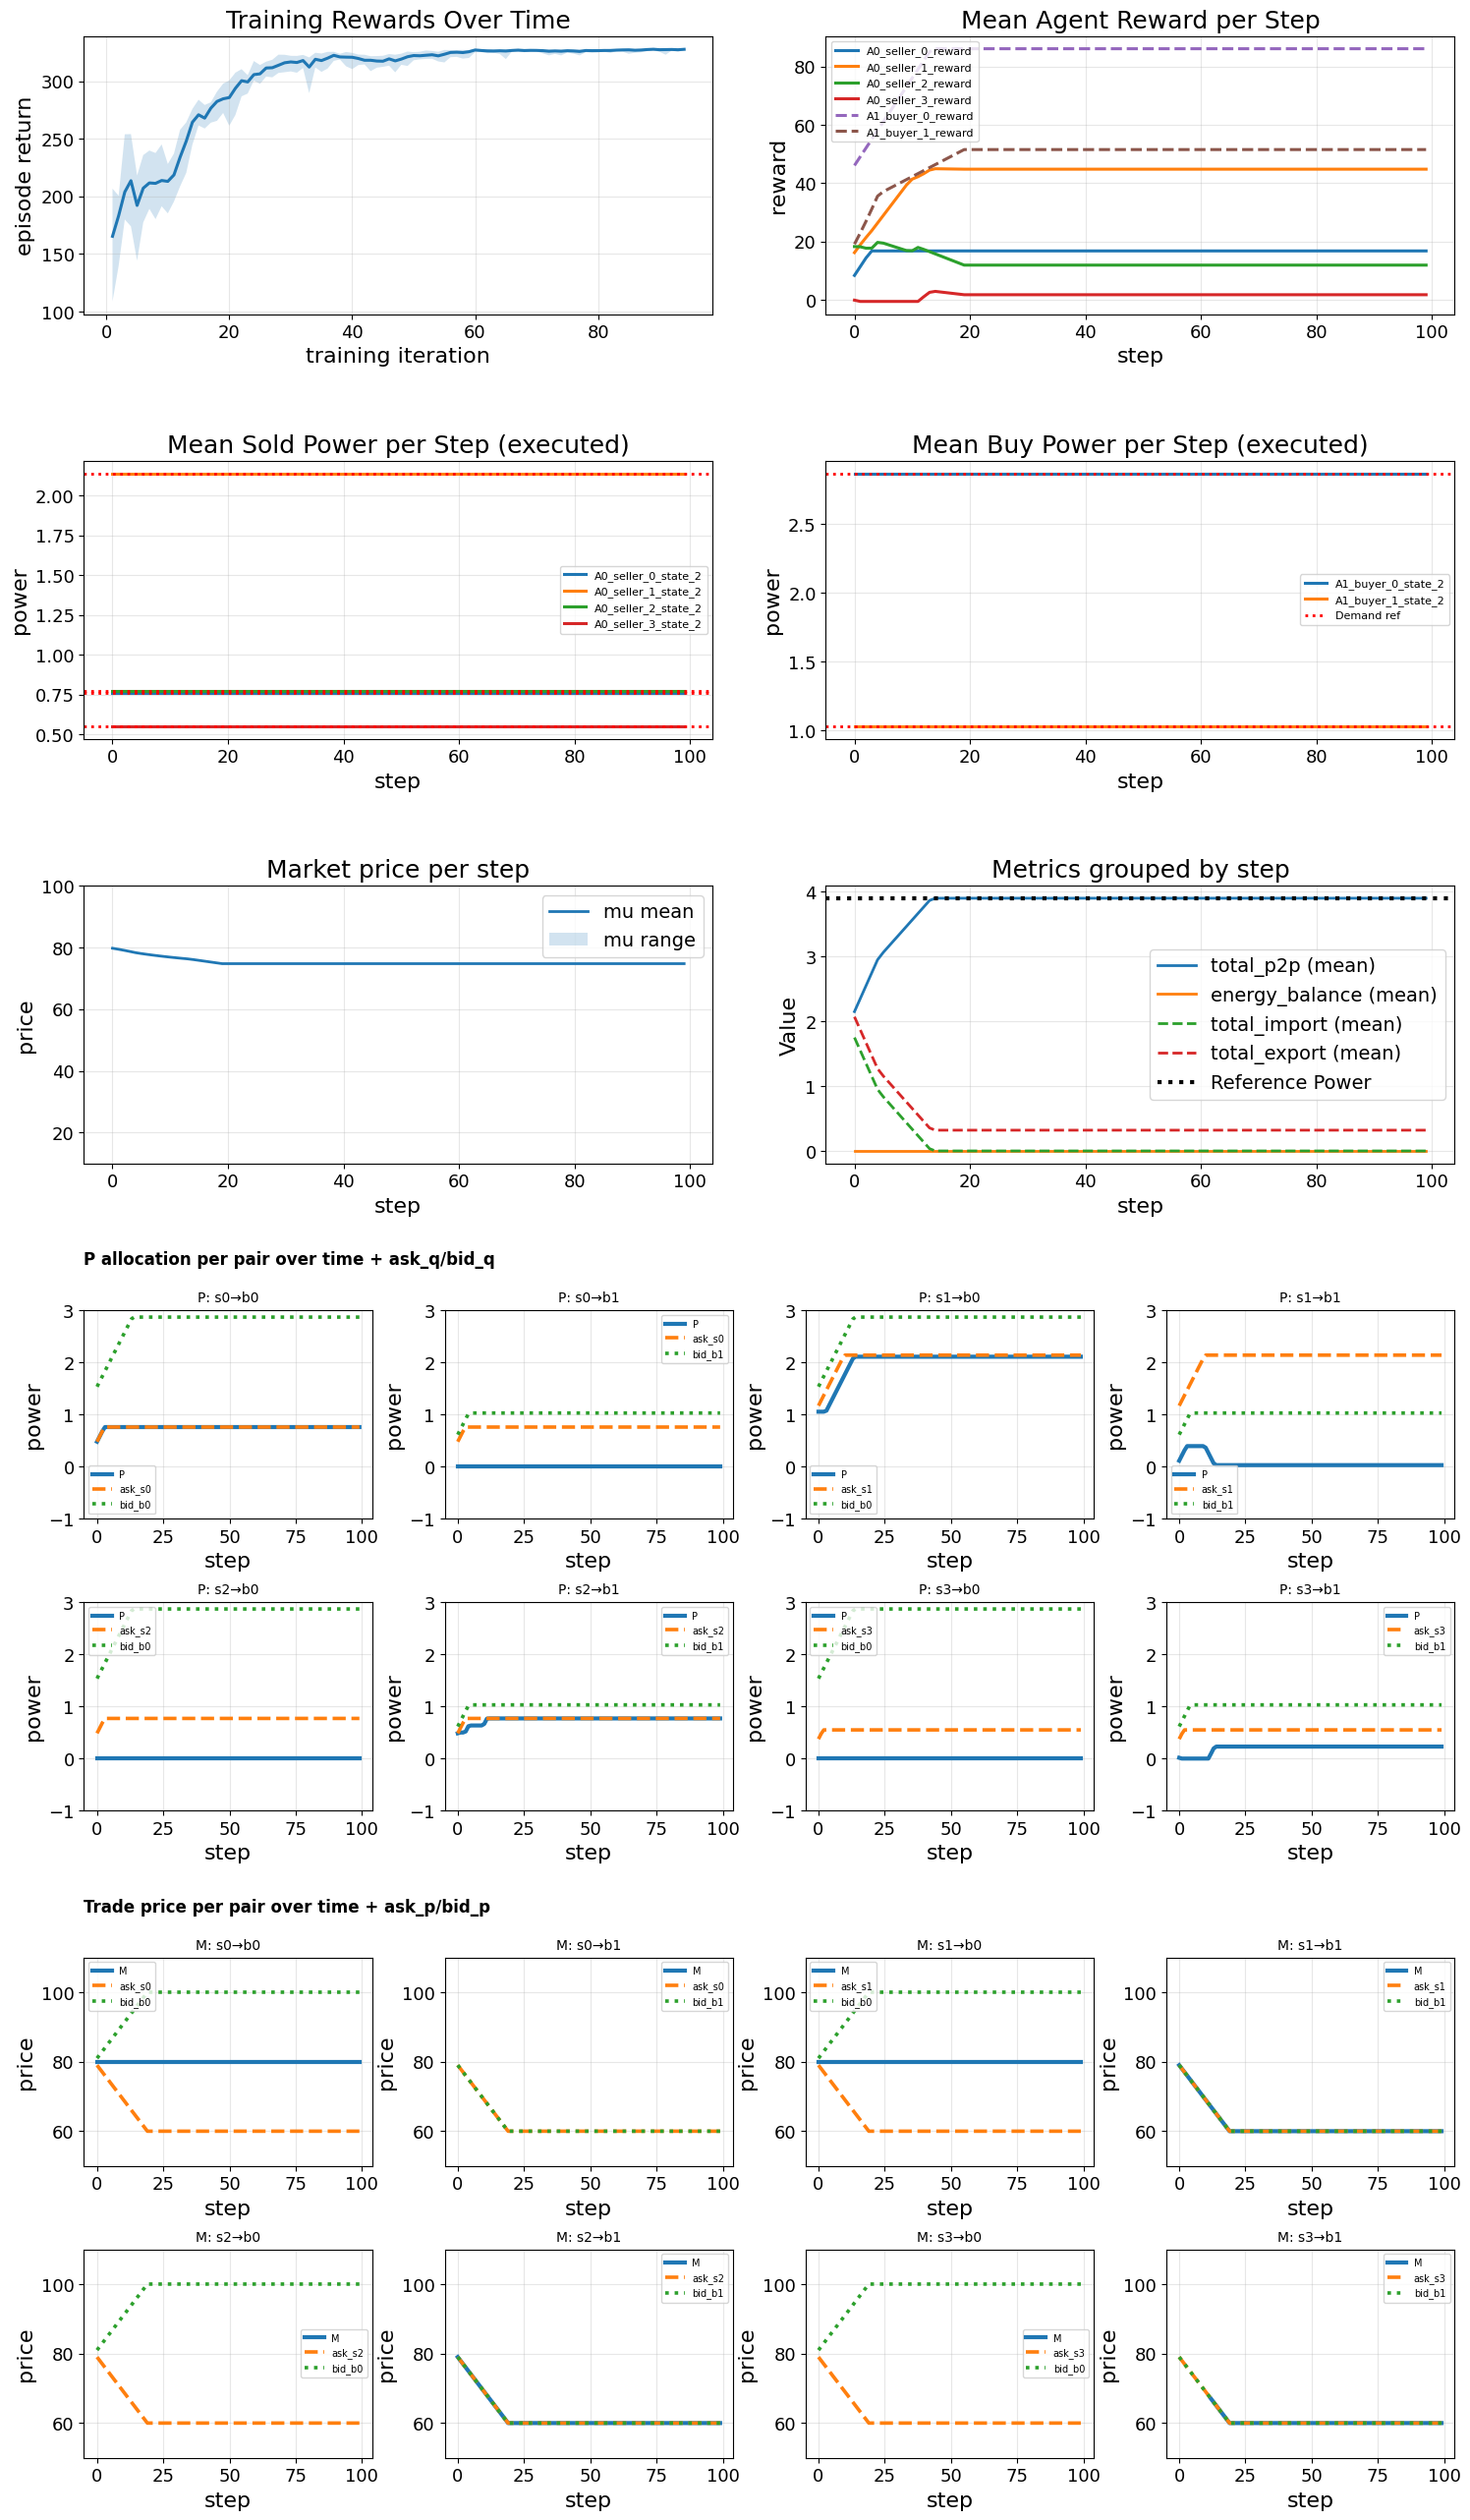

In [20]:
exp_name = "exp_results_2026-03-13_13-56-35"
algorithm = "PPO"
training_path = f"./{exp_name}/energy_market_training/{algorithm}_energy_market_run/progress.csv"
eval_path = f"./{exp_name}/energy_market_training/{algorithm}_energy_market_run/evaluation_agent_states.csv"
mu_path = f"./{exp_name}/energy_market_training/{algorithm}_energy_market_run/custom_metrics.csv"
# mu_path = f"./exp_results_2026-02-12_12-48-11/energy_market_training/PPO_energy_market_run/custom_metrics.csv"

full_analysis_plot(training_path, eval_path, mu_path, seller_power_reference=[0.76, 2.14, 0.77, 0.55, 2.87,1.03])